In [2]:
from scMM.file.data import CyESIData
import numpy as np
data = CyESIData("/home/zby/scMM/data/algea_results/raw/0mM-1/20260329-yz-0mM")#.normalize()

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
arg = np.argmin(np.abs(data.data.columns.astype(float)- 907.5224))
arg
data.data.columns[arg]

'907.5221515181166'

/tmp/ipykernel_351469/3461113582.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time_label",y="value",data=df,palette="Spectral_r",flierprops={"marker": "o", "markersize": 3})


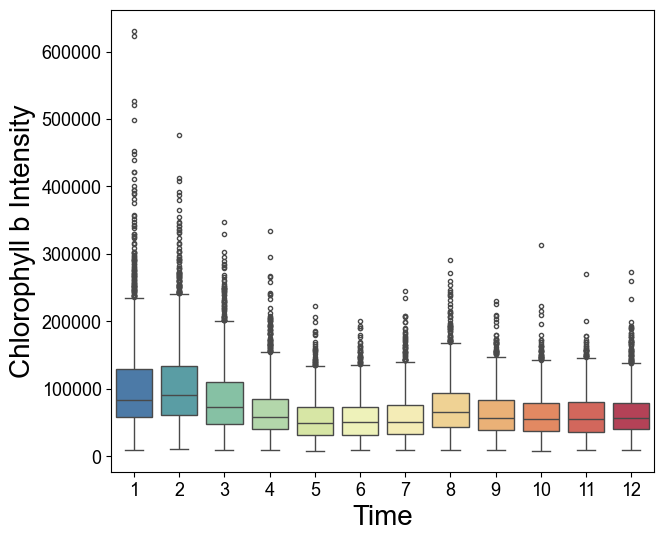

In [5]:
import scMM.plot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

time_bin = np.linspace(0, 1, 13)
labels = np.digitize(data.peak_meta["time"], time_bin[1:-1]) + 1
df = pd.DataFrame({"time_label": labels,"value": data.data.iloc[:, arg]})
df = df[df["value"] > 0]

plt.figure(figsize=(7, 6))
sns.boxplot(x="time_label",y="value",data=df,palette="Spectral_r",flierprops={"marker": "o", "markersize": 3})
plt.xlabel("Time", size=20)
plt.ylabel("Chlorophyll b Intensity", size=20)
plt.xticks(size=13)
plt.yticks(size=13)
plt.savefig("/home/zby/scMM/data/algea_results/res/0mM/Chlorophyll b_boxplot.svg")

/tmp/ipykernel_351469/2496390078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,x="Time",y="y",palette="Spectral_r",inner="quart",cut=0,


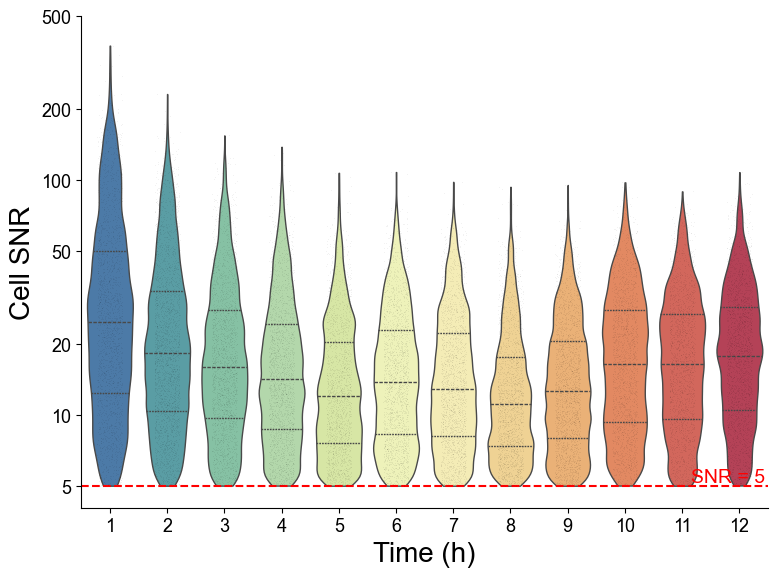

In [9]:
import matplotlib.pyplot as plt, seaborn as sns, pandas as pd, numpy as np

labels=np.digitize(data.peak_meta["time"],np.linspace(0,1,13)[1:-1])+1
df=pd.DataFrame({"Time":labels,"SNR":data.peak_meta["ref_snr"]}).query("SNR>0")
df["y"]=np.log10(df.SNR)

fig,ax=plt.subplots(figsize=(8,6))
sns.violinplot(data=df,x="Time",y="y",palette="Spectral_r",inner="quart",cut=0,
               density_norm="width",bw_adjust=.6,linewidth=1,ax=ax)
sns.stripplot(data=df,x="Time",y="y",color="k",size=.8,alpha=.06,jitter=.22,ax=ax)

ax.axhline(np.log10(5),ls="--",c="red",lw=1.5)
ticks=np.array([5,10,20,50,100,200,500])
ax.set(yticks=np.log10(ticks),yticklabels=ticks,xlabel="Time (h)",ylabel="Cell SNR")
ax.text(11.45,np.log10(5)+.015,"SNR = 5",c="red",ha="right")
ax.tick_params(labelsize=13); ax.xaxis.label.set_size(20); ax.yaxis.label.set_size(20)
sns.despine(); plt.tight_layout()
plt.savefig("/home/zby/scMM/data/algea_results/res/0mM/cell_snr.svg",bbox_inches="tight")

18969 1580.75


/tmp/ipykernel_6145/2792303096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=np.arange(1, 13), y=cell_counts, palette="Spectral_r")


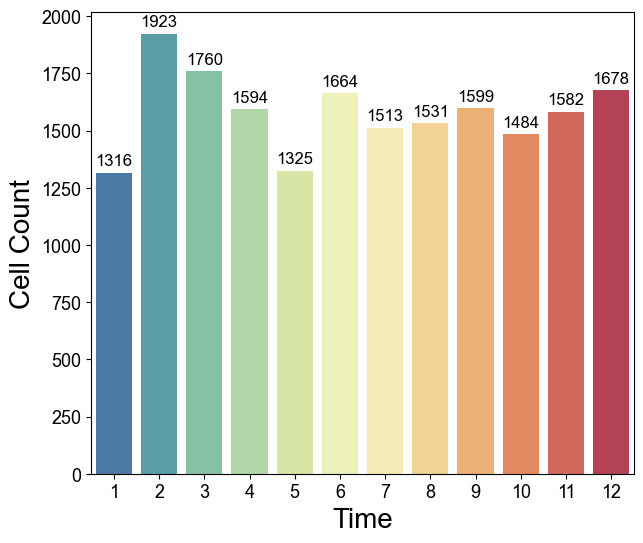

In [4]:
cell_counts = np.bincount(labels, minlength=13)[1:]
plt.figure(figsize=(7, 6))
ax = sns.barplot(x=np.arange(1, 13), y=cell_counts, palette="Spectral_r")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, size=12)
plt.xlabel("Time", size=20)
plt.ylabel("Cell Count", size=20)
plt.xticks(size=13)
plt.yticks(size=13)
print(np.sum(cell_counts), np.sum(cell_counts)/12)
#plt.savefig("/home/zby/scMM/data/algea_results/res/30mM/cell_count_barplot.svg")

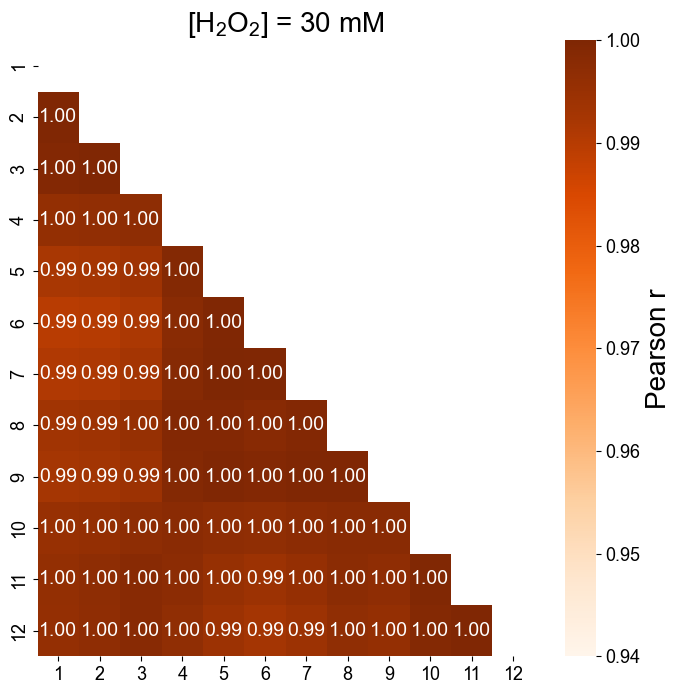

In [37]:
time_median = np.zeros((len(time_bin)-1, data.data.shape[1]))
for i in range(1, len(time_bin)):
    idx = np.where(labels == i)[0]
    time_median[i-1] = np.median(data.data.iloc[idx], axis=0)
plt.figure(figsize=(8,8))
corr_df = pd.DataFrame(data=np.corrcoef(time_median),index=np.arange(1, len(time_bin)),columns=np.arange(1, len(time_bin)))
ax = sns.heatmap(corr_df, annot=True, cmap="Oranges", vmin=0.94, vmax=1, fmt=".2f", mask=np.triu(np.ones_like(corr_df, dtype=bool)))
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)
cbar.set_label("Pearson r", size=20)
plt.xticks(size=13)
plt.yticks(size=13)
plt.title(r"[H$_2$O$_2$] = 30 mM", size=20)
plt.savefig("/home/zby/scMM/data/algea_results/res/30mM/time_median_correlation_heatmap.svg")

337.0


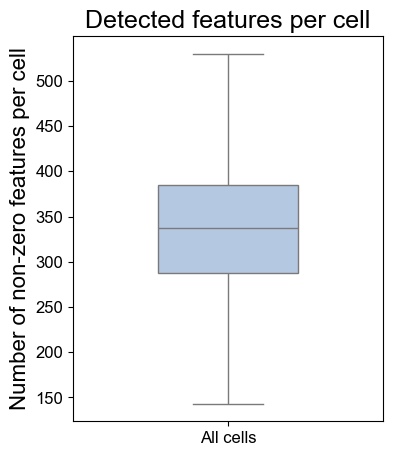

In [5]:
nonzero_features = (data.data > 0).sum(axis=1)
import seaborn as sns
qc_df = pd.DataFrame({
    "group": "All cells",
    "nonzero_features": nonzero_features
})

plt.figure(figsize=(4, 5))
sns.boxplot(
    data=qc_df,
    x="group",
    y="nonzero_features",
    width=0.45,
    showfliers=False,
    color = "#aec7e8"
)

print(qc_df["nonzero_features"].median())
plt.xlabel("")
plt.ylabel("Number of non-zero features per cell")
plt.title("Detected features per cell")
plt.savefig("/home/zby/scMM/data/algea_results/res/1mM/detected_features_count.svg")
plt.show()

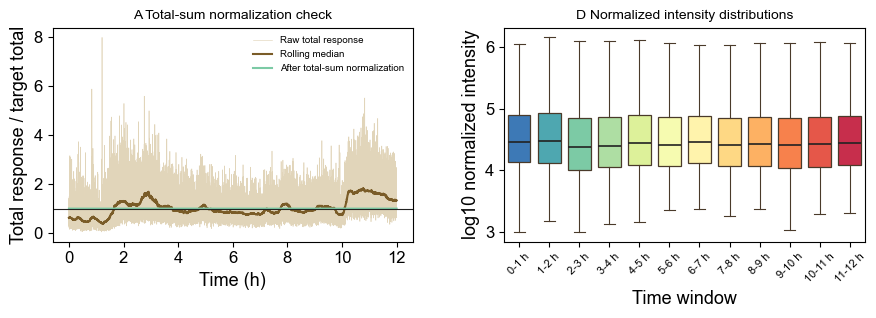

In [9]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

values = data.data.values.astype(float)
values[values < 0] = 0

cell_index = np.array([int(re.search(r"(\d+)$", x).group(1)) for x in data.data.index.astype(str)])
hours = cell_index / cell_index.max() * 12

idx = np.argsort(hours)
hours, values = hours[idx], values[idx]

raw_total = values.sum(axis=1)
target_total = np.median(raw_total[raw_total > 0])
normalized = values / raw_total[:, None] * target_total
normalized[~np.isfinite(normalized)] = 0

raw_ratio = raw_total / target_total
norm_ratio = normalized.sum(axis=1) / target_total

colors = sns.color_palette("Spectral_r", 12)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))

ax[0].plot(hours, raw_ratio, color="#d8c7a3", lw=0.45, alpha=0.75, label="Raw total response")
ax[0].plot(hours, pd.Series(raw_ratio).rolling(301, center=True, min_periods=60).median(),
           color="#7a5c28", lw=1.5, label="Rolling median")
ax[0].plot(hours, norm_ratio, color=colors[2], lw=1.5, label="After total-sum normalization")
ax[0].axhline(1, color="#222222", lw=0.8)
ax[0].set_xlabel("Time (h)", fontsize=13)
ax[0].set_ylabel("Total response / target total", fontsize=13)
ax[0].set_title("A Total-sum normalization check", fontweight="bold", fontsize=10)
ax[0].legend(frameon=False, fontsize=7)

rng = np.random.default_rng(20260403)
window_dist = []

for start in range(12):
    end = start + 1
    m = (hours >= start) & (hours <= end if end == 12 else hours < end)
    x = normalized[m, :]
    x = x[x > 0]
    if len(x) > 20000:
        x = rng.choice(x, 20000, replace=False)
    window_dist.append(np.log10(x))

bp = ax[1].boxplot(
    window_dist,
    tick_labels=[f"{i}-{i+1} h" for i in range(12)],
    showfliers=False,
    patch_artist=True,
    widths=0.75,
)

for p, c in zip(bp["boxes"], colors):
    p.set(facecolor=c, alpha=1, edgecolor="#4a3a2a", linewidth=0.9)

for x in bp["medians"]:
    x.set(color="#222222", lw=1.2)

for x in bp["whiskers"] + bp["caps"]:
    x.set(color="#4a3a2a", lw=0.8)

ax[1].set_xlabel("Time window", fontsize=13)
ax[1].set_ylabel("log10 normalized intensity", fontsize=13)
ax[1].set_title("D Normalized intensity distributions", fontweight="bold", fontsize=10)
ax[1].tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig("/home/zby/scMM/data/algea_results/res/1mM/panel_A_D_total_sum_normalization.svg", bbox_inches="tight")
plt.show()